<a href="https://colab.research.google.com/github/mahigarg0403-blip/Customer-purchase-prediction_mahi_bhumika/blob/main/notebooks/step3_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os
files = os.listdir('/content/drive/MyDrive/')
for f in files:
    if 'CPP' in f or 'ML' in f or 'MAHI' in f or 'BHUMIKA' in f:
        print(repr(f))

'1 - CPP – Number System.pdf'
'1 - CPP – Number System.gdoc'
'ESSAY- MAHI GARG - ENGLISH.gdoc'
'NSE HALL TICKET - MAHI.pdf'
'ENGLISH HHW MAHI GARG 9 H.gslides'
'MAHI GARG - CV.gdoc'
"DHAANI AND MAHI'S YOUTUBE CHANNEL.gdoc"
'03601192025_MAHI GARG_IDS PRACTICAL FILE.gdoc'
'CPP-ML PROJECT-BHUMIKA-MAHI'
'CPP-ML PROJECT- MAHI- BHUMIKA.gdoc'


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = '/content/drive/MyDrive/CPP-ML PROJECT-BHUMIKA-MAHI/'
df = pd.read_csv(path + 'cleaned_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (12205, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,2,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,2,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,2,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,2,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,2,1,0


In [8]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nRevenue distribution:\n", df['Revenue'].value_counts())

Shape: (12205, 18)

Columns: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']

Data types:
 Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                        int64
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                  int64
Weekend                      int64
Revenue                      int64
dtype: object

Revenue distribution

/tmp/ipykernel_2284/446893296.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Revenue', data=df, palette=['#e74c3c','#2ecc71'])


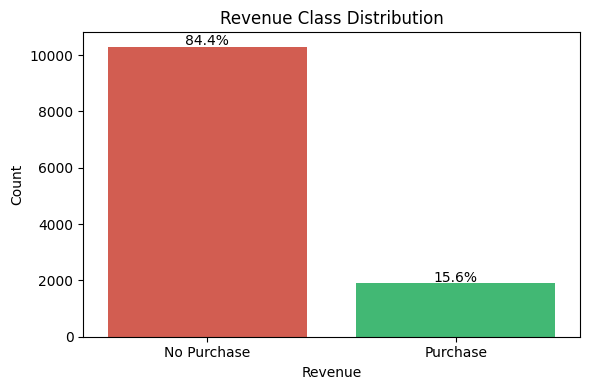

In [9]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Revenue', data=df, palette=['#e74c3c','#2ecc71'])
plt.title('Revenue Class Distribution')
plt.xticks([0,1], ['No Purchase', 'Purchase'])
plt.xlabel('Revenue')
plt.ylabel('Count')

total = len(df)
for p in ax.patches:
    percentage = f'{100*p.get_height()/total:.1f}%'
    ax.annotate(percentage, (p.get_x()+p.get_width()/2, p.get_height()+50), ha='center')

plt.tight_layout()
plt.savefig('plot1_class_distribution.png', dpi=150)
plt.show()

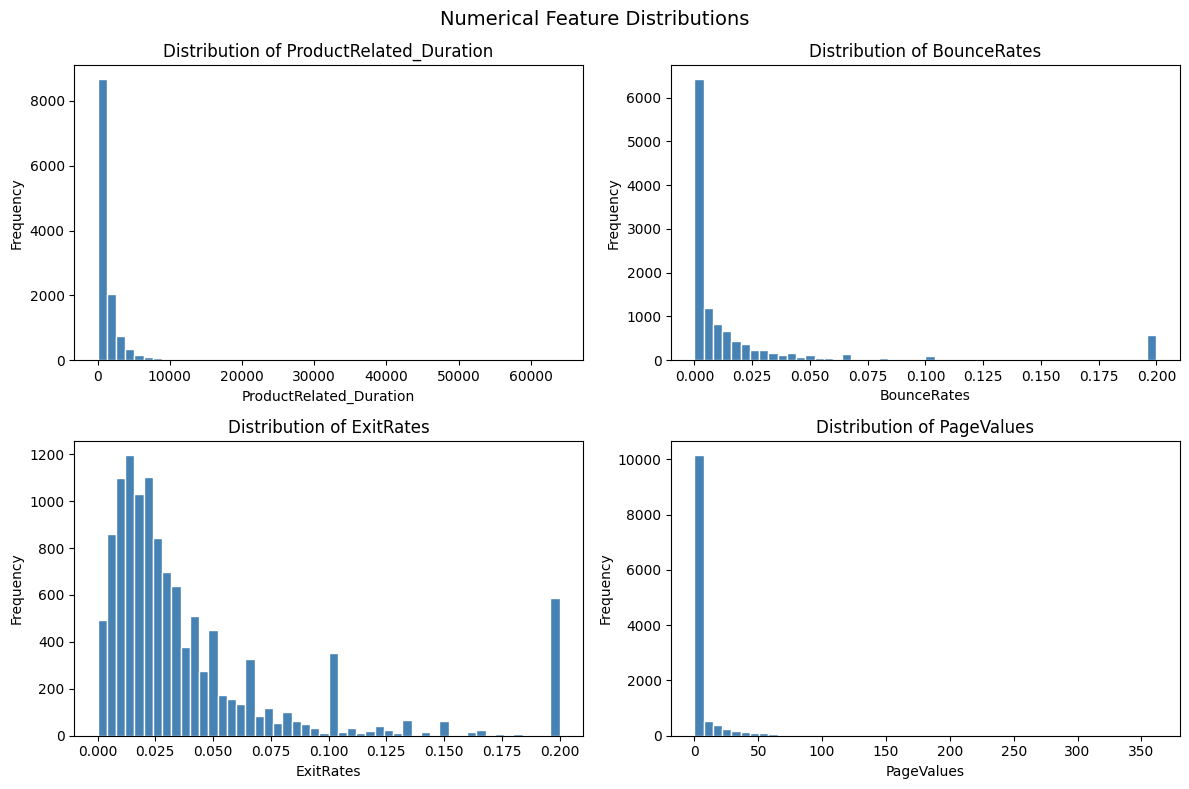

In [10]:
cols = ['ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Numerical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('plot2_numerical_distributions.png', dpi=150)
plt.show()

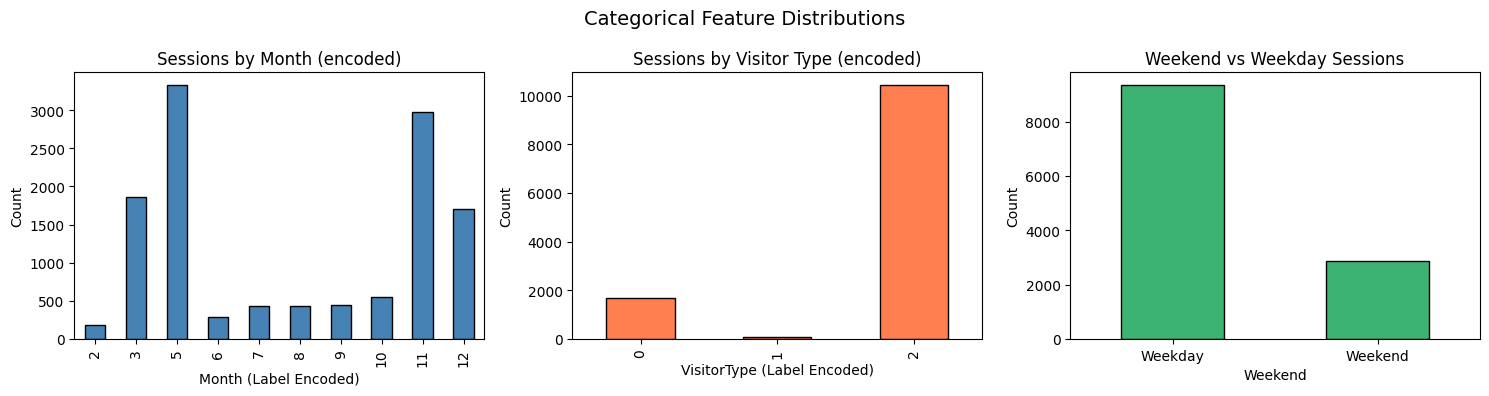

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Month distribution
df['Month'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Sessions by Month (encoded)')
axes[0].set_xlabel('Month (Label Encoded)')
axes[0].set_ylabel('Count')

# VisitorType distribution
df['VisitorType'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Sessions by Visitor Type (encoded)')
axes[1].set_xlabel('VisitorType (Label Encoded)')
axes[1].set_ylabel('Count')

# Weekend distribution
df['Weekend'].value_counts().plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='black')
axes[2].set_title('Weekend vs Weekday Sessions')
axes[2].set_xticklabels(['Weekday', 'Weekend'], rotation=0)
axes[2].set_ylabel('Count')

plt.suptitle('Categorical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('plot3_categorical_distributions.png', dpi=150)
plt.show()

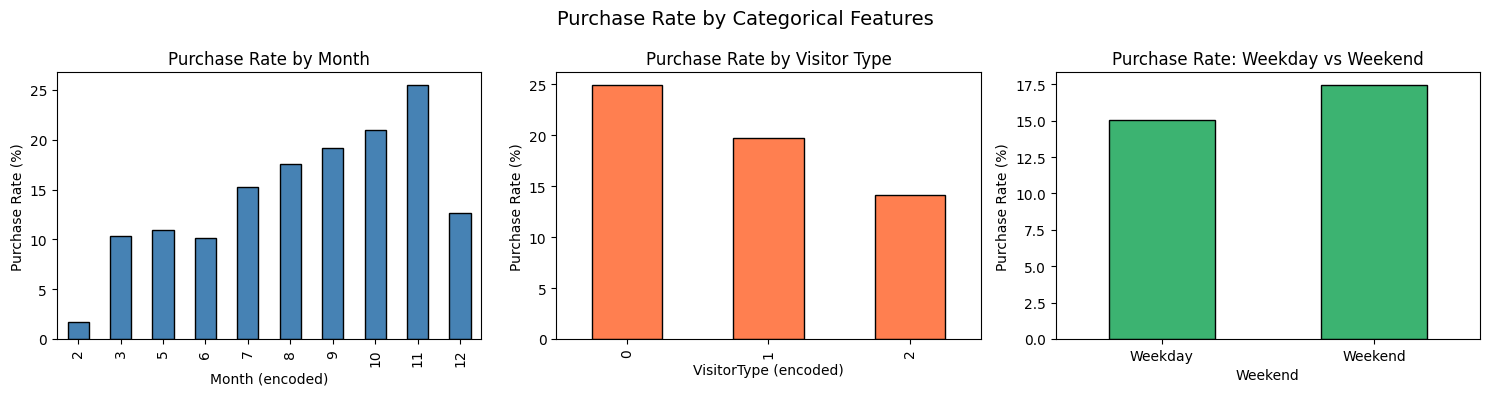

Purchase rate by Month:
 Month
2      1.657459
3     10.322581
5     10.964254
6     10.175439
7     15.277778
8     17.551963
9     19.196429
10    20.947177
11    25.486251
12    12.661196
Name: Revenue, dtype: float64

Purchase rate by VisitorType:
 VisitorType
0    24.926167
1    19.753086
2    14.092609
Name: Revenue, dtype: float64

Purchase rate by Weekend:
 Weekend
0    15.075968
1    17.453655
Name: Revenue, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# By Month
month_rev = df.groupby('Month')['Revenue'].mean() * 100
month_rev.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Purchase Rate by Month')
axes[0].set_xlabel('Month (encoded)')
axes[0].set_ylabel('Purchase Rate (%)')

# By VisitorType
visitor_rev = df.groupby('VisitorType')['Revenue'].mean() * 100
visitor_rev.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Purchase Rate by Visitor Type')
axes[1].set_xlabel('VisitorType (encoded)')
axes[1].set_ylabel('Purchase Rate (%)')

# By Weekend
weekend_rev = df.groupby('Weekend')['Revenue'].mean() * 100
weekend_rev.plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='black')
axes[2].set_xticklabels(['Weekday', 'Weekend'], rotation=0)
axes[2].set_title('Purchase Rate: Weekday vs Weekend')
axes[2].set_ylabel('Purchase Rate (%)')

plt.suptitle('Purchase Rate by Categorical Features', fontsize=14)
plt.tight_layout()
plt.savefig('plot4_bivariate_categorical.png', dpi=150)
plt.show()

# Print actual numbers
print("Purchase rate by Month:\n", month_rev)
print("\nPurchase rate by VisitorType:\n", visitor_rev)
print("\nPurchase rate by Weekend:\n", weekend_rev)

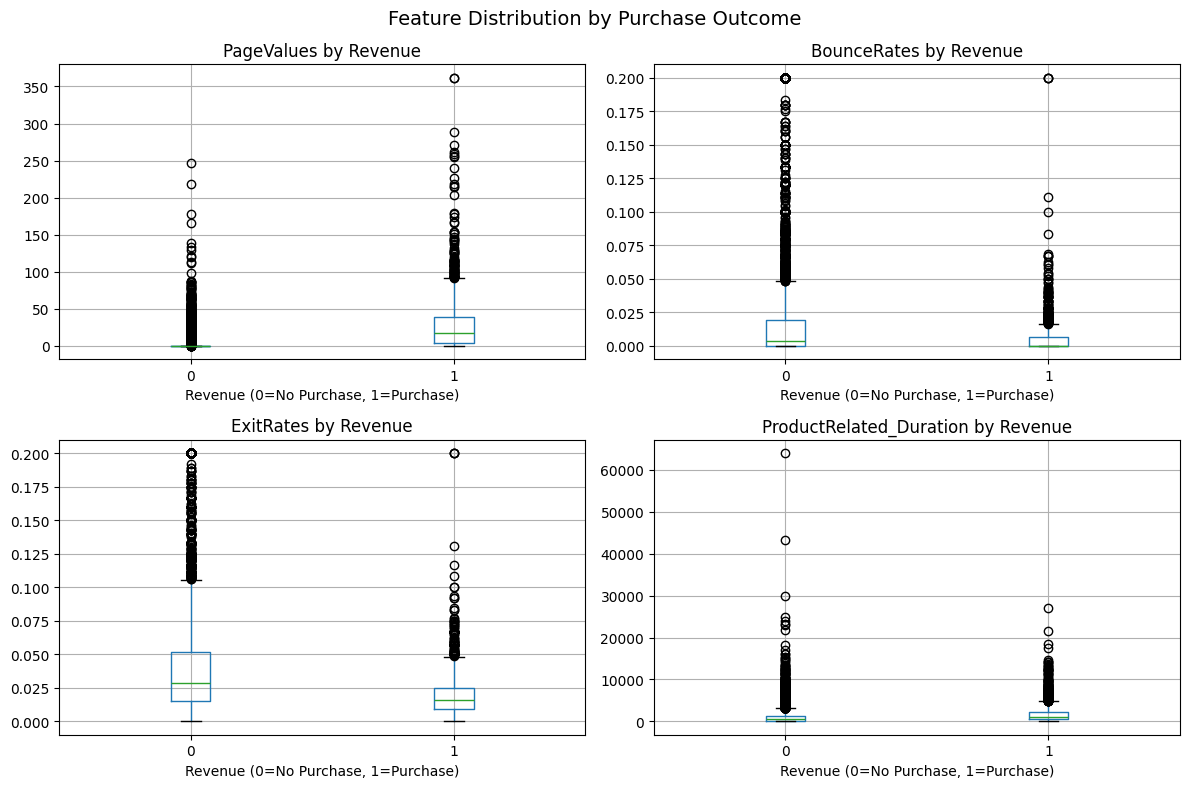

In [13]:
cols = ['PageValues', 'BounceRates', 'ExitRates', 'ProductRelated_Duration']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    df.boxplot(column=col, by='Revenue', ax=axes[i])
    axes[i].set_title(f'{col} by Revenue')
    axes[i].set_xlabel('Revenue (0=No Purchase, 1=Purchase)')

plt.suptitle('Feature Distribution by Purchase Outcome', fontsize=14)
plt.tight_layout()
plt.savefig('plot5_boxplots.png', dpi=150)
plt.show()

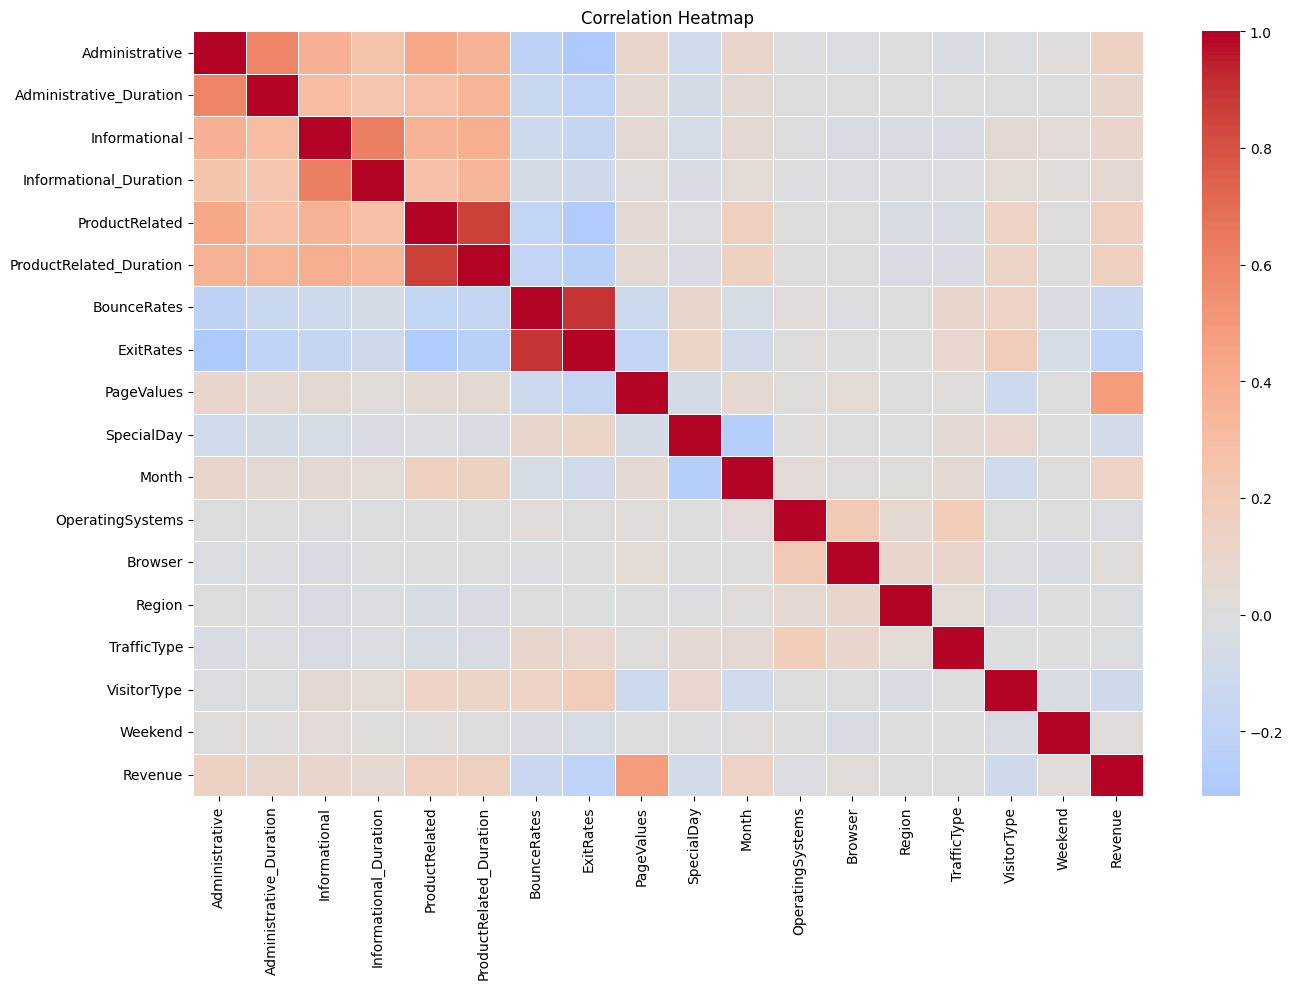

In [14]:
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix,
            annot=False,
            cmap='coolwarm',
            center=0,
            linewidths=0.5)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('plot6_correlation_heatmap.png', dpi=150)
plt.show()

In [17]:
rev_corr = corr_matrix['Revenue'].drop('Revenue').sort_values(ascending=False)

print("Top features correlated with Revenue:")
print(rev_corr.head(10))
print("\nNegative correlations:")
print(rev_corr.tail(5))
print("\nBounceRates vs ExitRates correlation:",
      round(corr_matrix.loc['BounceRates','ExitRates'], 3))

Top features correlated with Revenue:
PageValues                 0.491894
ProductRelated             0.156042
ProductRelated_Duration    0.150077
Administrative             0.136330
Month                      0.126412
Informational              0.093626
Administrative_Duration    0.091768
Informational_Duration     0.069358
Weekend                    0.027729
Browser                    0.024052
Name: Revenue, dtype: float64

Negative correlations:
OperatingSystems   -0.014927
SpecialDay         -0.083601
VisitorType        -0.103469
BounceRates        -0.145091
ExitRates          -0.204320
Name: Revenue, dtype: float64

BounceRates vs ExitRates correlation: 0.902


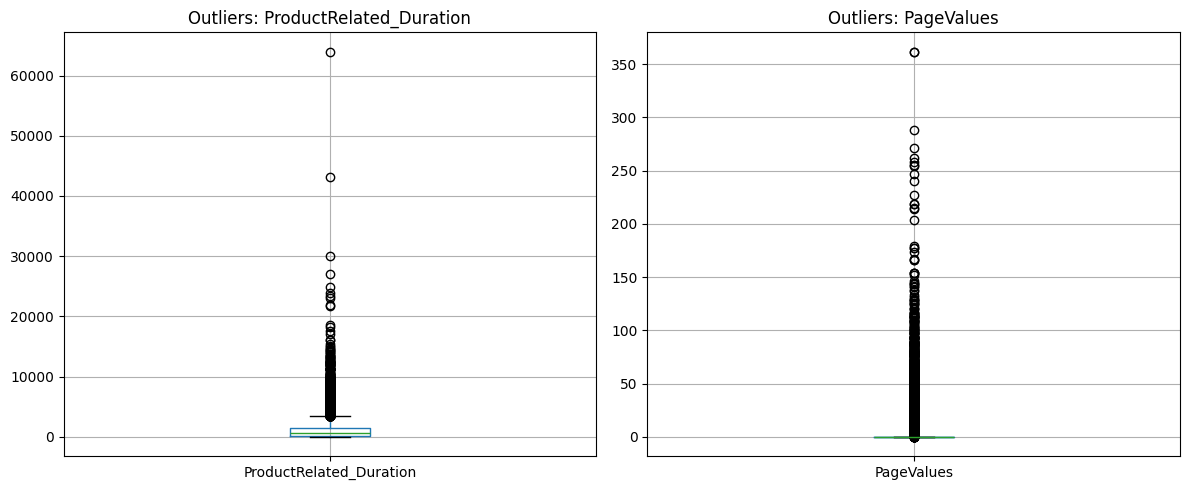

ProductRelated_Duration: 951 outliers (7.8%)
PageValues: 2730 outliers (22.4%)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.boxplot(column='ProductRelated_Duration', ax=axes[0])
axes[0].set_title('Outliers: ProductRelated_Duration')

df.boxplot(column='PageValues', ax=axes[1])
axes[1].set_title('Outliers: PageValues')

plt.tight_layout()
plt.savefig('plot7_outliers.png', dpi=150)
plt.show()

for col in ['ProductRelated_Duration', 'PageValues']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers ({100*len(outliers)/len(df):.1f}%)")

In [16]:
import shutil

plots = ['plot1_class_distribution.png',
         'plot2_numerical_distributions.png',
         'plot3_categorical_distributions.png',
         'plot4_bivariate_categorical.png',
         'plot5_boxplots.png',
         'plot6_correlation_heatmap.png',
         'plot7_outliers.png']

for plot in plots:
    shutil.copy(plot, path + plot)
    print(f"Saved {plot} to Drive ✅")

Saved plot1_class_distribution.png to Drive ✅
Saved plot2_numerical_distributions.png to Drive ✅
Saved plot3_categorical_distributions.png to Drive ✅
Saved plot4_bivariate_categorical.png to Drive ✅
Saved plot5_boxplots.png to Drive ✅
Saved plot6_correlation_heatmap.png to Drive ✅
Saved plot7_outliers.png to Drive ✅
